# Loop GPT
Using the structured output API from OpenAI, this code prompts the gpt-4o to generate a 4 bar MIDI loop. This loop is a combination of a chord progression and a melody.

### Set Imports

In [1]:
from dotenv import load_dotenv
from pydantic import BaseModel, field_validator, ValidationError, Field
from openai import OpenAI

from mido import MidiFile, MidiTrack, Message
import matplotlib.pyplot as plt
import numpy as np
import os, pygame, pretty_midi

pygame 2.6.0 (SDL 2.28.4, Python 3.12.2)
Hello from the pygame community. https://www.pygame.org/contribute.html


### Set OpenAI API Key

In [2]:
load_dotenv("C:\\Users\\Patrick\\Desktop\\PROJECTS\\OpenAI Sandbox\\.env")
client = OpenAI(api_key=os.getenv('SANDBOX_API_KEY'))

### Create the objects that the model will generate

In [3]:
class Note(BaseModel):
    pitch: str = Field(..., description='Pitch of the note (e.g. "C", "D", "E", "F", "G", "A", "B")')
    octave: int = Field(..., description='Octave of the note (e.g. 1-8)')
    velocity: int = Field(..., description='Velocity of the note (e.g. 0-127)') 
    
class TimeInformation(BaseModel):
    start_beat: int = Field(..., description="Start beat of the chord (e.g. 1-4)")  # Start beat of the chord (e.g. 1-4)
    duration: int = Field(..., description="Duration of the chord (e.g. 1-4)")  # Duration of the chord (e.g. 1-4)

class Chord(BaseModel):
    root: str = Field(..., description='Root note of the chord (e.g. "C", "D", "E", "F", "G", "A", "B")')
    quality: str = Field(..., description='Quality of the chord (e.g. "major", "minor", "diminished", "augmented", "dominant")')
    voicing: list[Note] = Field(..., description='List of notes in the chord')
    time: TimeInformation

class Bar(BaseModel):
    num: int = Field(..., description='Number of the bar (e.g. 1-4)')
    chords: list[Chord] = Field(..., description='List of chords in the bar')
    
    @field_validator('chords')
    def check_total_beats(cls, chords):
        total_duration = sum(chord.time.duration for chord in chords)
        if total_duration > 4:
            raise ValueError(f'Total duration of chords in the bar must not exceed 4 beats, but got {total_duration}')
        return chords

## Generation

In [4]:
def generate_chords(key, mode, keywords, temp=0.0):
    """ Generates a 4 bar MIDI chord progression based on the key, mode, and keywords provided.

    Args:
        key (str): The key of the chord progression (e.g. "C", "D", "E", "F", "G", "A", "B")
        mode (str): The mode of the chord progression (e.g. "major", "minor")
        keywords (str): Keywords to guide the generation of the chord progression (e.g. "daniel ceasar rnb with extensions", "gospel with pushed rythym", "basic pop triads")
    
    Returns:
        List of Bar Objects: A list of 4 Bar objects, each containing a list of Chord objects
    """
    # Initialize the message list with the system message and the formatted user message
    messages = [
        {"role": "system", "content": "You are a MIDI Generator. I will give you a prompt and you will generate a 4 bar chord progression. You will generate the progression bar by bar. Try to make the chord progression develops and not just repeat on the same bar. Try not to make the rythym boring. The progression is only 4 bars long with 4 beats each. Make sure to voice the chords in a way that sounds good. Always make sure that the root note are included and are the lowest note in the chord."},
        {"role": "user", "content": f"Generate in {key} {mode}. Keywords: {keywords}"},
    ]
    # Initialize the list of bars
    bars = []
    # Loop through for 4 bars of generation
    for i in range(4):
        # Try/Except block to catch any validation errors - Work on the error handling later
        try:
            # Make the API call to generate a bar of MIDI data based on the message list
            completion = client.beta.chat.completions.parse(
                model="gpt-4o-2024-08-06",
                messages=messages,
                response_format=Bar,
                temperature=temp
            )
            midi_loop = completion.choices[0].message.parsed
            bars.append(midi_loop)
            # Append the bar of MIDI data to the message list to be used as context for the next bar's generation
            messages.append(
                {
                    "role": "assistant", 
                    "content": f"{midi_loop}"
                }
            )
            # Append a user message to prompt the user to continue the chord progression
            messages.append(
                {
                    "role": "user",
                    "content": "Continue the chord progression with generating the next bar. Remember that the progression is only 4 bars long."
                }
            )
            print(midi_loop)
            
        except ValidationError as e:
            print(f"Validation error: {e}")
        
    return bars, messages

## Post-Processing

### Convert note names to note numbers
When the GPT model generates the chord progression, it generates the note name and octave instead of the MIDI number we are looking to use for creating the MIDI file using mido.

In [5]:
# A dictionary that maps note names to their corresponding MIDI numbers
base_midi_numbers = {"C": 0, "B##": 1, "C#": 1,"D♭": 1,"Db": 1, "C##": 2, "D": 2, "D#": 3, "E♭": 3, "Eb": 3,"D##": 4, "E": 4, "Fb": 4, "F♭": 4, "E#": 5, "F": 5, "E##": 6, "F#": 6, "Gb": 6, "G♭": 6, "F##": 7, "G": 7, "G#": 8, "A♭": 8, "Ab": 8, "G##": 9, "A": 9, "A#": 10, "B♭": 10, "Bb": 10, "A##": 11, "B": 11, "Cb": 11, "C♭": 11, "B#": 12}

# Function to calculate MIDI number
def calculate_midi_number(note):
    """Calculates the MIDI number for a given note.

    Args:
        note (Note Object): The note object that holds the pitch and octave of the note.

    Returns:
        int: A MIDI number that corresponds to the note.
    """
    # Get the number associated with the note's pitch from the dictionary
    base_number = base_midi_numbers[note.pitch] 
    # Calculate the MIDI number using the base number and octave
    midi_number = base_number + ((note.octave + 1) * 12)
    return midi_number

In [6]:
# Example usage
note = Note(pitch="C", octave=4, velocity=127)
midi_number = calculate_midi_number(note)
print(f"MIDI number for {note.pitch}{note.octave} is {midi_number}")

MIDI number for C4 is 60


### Create the MIDI file

In [7]:
def convert_midi_file(bars, output_filename):
    midi = MidiFile()
    track = MidiTrack()
    midi.tracks.append(track)
    
    # Set the ticks per beat
    ticks_per_beat = 480

    # Iterate through each bar
    for bar in bars:
        # Iterate through each chord in the bar
        # print(bar)
        past_event_time = 0
        for chord in bar.chords:
            # print(chord.time)
            
            # Calculate the note_on and note_off times
            note_on_time = (chord.time.start_beat - 1) * ticks_per_beat - past_event_time
            note_off_time = chord.time.duration * ticks_per_beat

            # Add note_on events for each note in the chord
            for note in chord.voicing:
                track.append(Message('note_on', note=calculate_midi_number(note), velocity=note.velocity, time=note_on_time))
            
            # Add note_off events for each note in the chord
            for i, note in enumerate(chord.voicing):
                if i == 0:
                    # First note off message with time = ticks_per_bar
                    track.append(Message('note_off', note=calculate_midi_number(note), velocity=note.velocity, time=note_off_time))
                else:
                    # Subsequent note off messages with time = 0
                    track.append(Message('note_off', note=calculate_midi_number(note), velocity=note.velocity, time=0))

            # Update the past event time
            past_event_time = note_off_time

    # Save the MIDI file
    midi.save(f"loop_generations/{output_filename}")
    print(f"MIDI file saved as loop_generations/{output_filename}")

In [8]:
def play_midi(midi_file):
    # Initialize pygame mixer
    pygame.mixer.init()
    pygame.mixer.music.load(midi_file)
    # Play the MIDI file
    pygame.mixer.music.play()

In [9]:
def midi_to_note_name(midi_numbers):
    octave = midi_numbers // 12 - 1
    note_names = np.array(['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B'])
    return [f'{note}{oct}' for note, oct in zip(note_names[midi_numbers % 12], octave)]

def visualize_midi(midi_file):
    """
    Visualize a MIDI file using prettyMIDI to get the MIDI analysis data and matplotlib to create the display.

    Args:
        midi_file (str): The filename of the MIDI file to play and visualize.
    """
    # Load the MIDI file
    midi_data = pretty_midi.PrettyMIDI(midi_file)
    # Extract the piano roll
    piano_roll = midi_data.get_piano_roll(fs=100)
    
    # Find the lowest and highest active notes
    active_notes = np.where(piano_roll > 0)[0]
    lowest_note = np.min(active_notes)
    highest_note = np.max(active_notes)
    # Define padding (in number of MIDI notes)
    padding = 5  # Adjust this value as needed
    # Calculate the note range with padding
    min_note = max(0, lowest_note - padding)
    max_note = min(127, highest_note + padding)
    cropped_piano_roll = piano_roll[min_note:max_note + 1]

    tempo = 120
    # Get the time per beat and per bar
    seconds_per_beat = 60.0 / tempo
    seconds_per_bar = seconds_per_beat * 4
    
    # Calculate the positions of bars and beats
    total_frames = cropped_piano_roll.shape[1]
    time_per_frame = midi_data.get_end_time() / total_frames
    bar_positions = np.arange(0, total_frames, seconds_per_bar / time_per_frame)
    beat_positions = np.arange(0, total_frames, seconds_per_beat / time_per_frame)

    # Create the plot
    plt.figure(figsize=(12, 8))
    plt.imshow(cropped_piano_roll, aspect='auto', cmap='gray_r', origin='lower', interpolation='nearest')

    # Add grid lines at the top and bottom of each note block
    note_range = np.arange(min_note, max_note + 1)
    for i in range(len(note_range)):
        plt.hlines(i + 0.5, xmin=0, xmax=cropped_piano_roll.shape[1], color='gray', linestyle='--', linewidth=0.5)
        plt.hlines(i - 0.5, xmin=0, xmax=cropped_piano_roll.shape[1], color='gray', linestyle='--', linewidth=0.5)

    # Set y-axis ticks to note names
    plt.yticks(ticks=np.arange(len(note_range)), labels=midi_to_note_name(note_range))

    # Set x-axis ticks to bars and beats
    plt.xticks(ticks=bar_positions, labels=[f'Bar {i+1}' for i in range(len(bar_positions))])
    for beat_position in beat_positions:
        plt.axvline(x=beat_position, color='gray', linestyle='--', linewidth=0.5)

    # Set labels and title
    plt.xlabel('Bars and Beats')
    plt.ylabel('MIDI Note')
    plt.title(midi_file)
    plt.colorbar(label='Velocity')

    # Display the plot
    plt.show()

# Create a counter melody for the chord progression

In [10]:
class MelodyNote(BaseModel):
    pitch: str = Field(..., description='Pitch of the note (e.g. "C", "D", "E", "F", "G", "A", "B")')
    octave: int = Field(..., description='Octave of the note (e.g. 1-8)')
    velocity: int = Field(..., description='Velocity of the note (e.g. 0-127)')
    time: TimeInformation 

class MelodyBar(BaseModel):
    num: int = Field(..., description='Number of the bar (e.g. 1-4)')
    melody: list[MelodyNote] = Field(..., description='List of notes in the bar')
    
    @field_validator('melody')
    def check_total_beats(cls, melody):
        total_duration = sum(note.time.duration for note in melody)
        if total_duration > 4:
            raise ValueError(f'Total duration of melody in the bar must not exceed 4 beats, but got {total_duration}')
        return melody

In [11]:
def generate_melody(messages, temp=0.0):
    # Add a user message to prompt the model to create a melody using the chords generated
    messages.append({"role": "user", "content": "Now create a melody using the chords you generated. You will generate the melody in the same bar by bar fashion that you did with the chords. Make sure that every note is in the same key and scale. Please do not just generate a arpeggiation of the chords. Try to have a rythymic theme that is not just straight 4ths. Try to have at least one note with a duration that is more than 1. Also make sure that the total melody loop is the same length as the chord progression (4 bars)."})
    # Initialize the list of melody bars
    melody_bars = []
    # Loop through for 4 bars of generation
    for i in range(4):
        # Try/Except block to catch any validation errors - Work on the error handling later
        try:
            # Make the API call to generate a bar of MIDI data based on the message list
            completion = client.beta.chat.completions.parse(
                model="gpt-4o-2024-08-06",
                messages=messages,
                response_format=MelodyBar,
                temperature=temp
            )
            midi_loop = completion.choices[0].message.parsed
            melody_bars.append(midi_loop)
            # Append the bar of MIDI data to the message list to be used as context for the next bar's generation
            messages.append(
                {
                    "role": "assistant", 
                    "content": f"{midi_loop}"
                }
            )
            # Append a user message to prompt the user to continue the melody generation
            messages.append(
                {
                    "role": "user",
                    "content": "Continue the melody generation with the next bar. Remember that the progression is only 4 bars long."
                }
            )
            print(midi_loop)
            
        except ValidationError as e:
            print(f"Validation error: {e}")
    
    return melody_bars

In [12]:
def add_melody_to_midi(melody_bars, existing_midi_filename, output_filename):
    # Load the existing MIDI file
    existing_midi = MidiFile(existing_midi_filename)
    # Create a new MIDI file to write the merged data
    merged_midi = MidiFile()
    # Copy the tracks from the existing MIDI file to the merged MIDI file
    for track in existing_midi.tracks:
        merged_midi.tracks.append(track)
    # Create a new track for the melody data
    melody_track = MidiTrack()
    merged_midi.tracks.append(melody_track)
    # Calculate the total ticks per beat
    ticks_per_beat = existing_midi.ticks_per_beat

    # Initialize the past event time
    past_event_time = 0
    # Iterate through each melody bar and add the notes to the melody track
    for melody_bar in melody_bars:
        for note in melody_bar.melody:
            # Calculate the note on and note off times in ticks
            note_off_time = note.time.duration * ticks_per_beat
            note_on_time = (note.time.start_beat - 1) * ticks_per_beat - past_event_time
            # Ensure the note on time is not negative
            if note_on_time < 0:
                note_on_time = 0
                
            # Create note on and note off messages and add them to the melody track
            melody_track.append(Message('note_on', note=calculate_midi_number(note), velocity=note.velocity, time=note_on_time))
            melody_track.append(Message('note_off', note=calculate_midi_number(note), velocity=note.velocity, time=note_off_time))
            
            # Update the past event time
            past_event_time += note_on_time + note_off_time
            
    # Save the merged MIDI file
    merged_midi.save(f"loop_generations/{output_filename}")
    print(f"MIDI file saved as loop_generations/{output_filename}")

# Main Processing Steps

In [13]:
# Prompt the user for the key, scale, and any keywords for the MIDI generation
key = input("Enter the key (ex. Db): ")
mode = input("Enter the scale (ex. major): ")
keywords = input("Enter any keywords (ex. Artist Names, Genre, Voicing style): ")
t = float(input("Enter the temperature (ex. 0.0): "))

In [14]:
cp_gen, msgs = generate_chords(key, mode, keywords, t)
convert_midi_file(cp_gen, f"{t}/{key} {mode} {keywords}.mid")
visualize_midi(f"loop_generations/{t}/{key} {mode} {keywords}.mid")
play_midi(f"loop_generations/{t}/{key} {mode} {keywords}.mid")

BadRequestError: Error code: 400 - {'error': {'message': "Invalid schema for response_format 'Bar': In context=('properties', 'time'), 'additionalProperties' is required to be supplied and to be false.", 'type': 'invalid_request_error', 'param': 'response_format', 'code': None}}

num=1 melody=[MelodyNote(pitch='B', octave=4, velocity=85, time=TimeInformation(start_beat=1, duration=1)), MelodyNote(pitch='D', octave=5, velocity=90, time=TimeInformation(start_beat=2, duration=2)), MelodyNote(pitch='F#', octave=4, velocity=80, time=TimeInformation(start_beat=4, duration=1))]
num=2 melody=[MelodyNote(pitch='A', octave=4, velocity=85, time=TimeInformation(start_beat=1, duration=1)), MelodyNote(pitch='C#', octave=5, velocity=90, time=TimeInformation(start_beat=2, duration=1)), MelodyNote(pitch='E', octave=4, velocity=80, time=TimeInformation(start_beat=3, duration=2))]
num=3 melody=[MelodyNote(pitch='D', octave=5, velocity=85, time=TimeInformation(start_beat=1, duration=1)), MelodyNote(pitch='F#', octave=4, velocity=90, time=TimeInformation(start_beat=2, duration=1)), MelodyNote(pitch='A', octave=4, velocity=80, time=TimeInformation(start_beat=3, duration=2))]
num=4 melody=[MelodyNote(pitch='G', octave=4, velocity=85, time=TimeInformation(start_beat=1, duration=1)), M

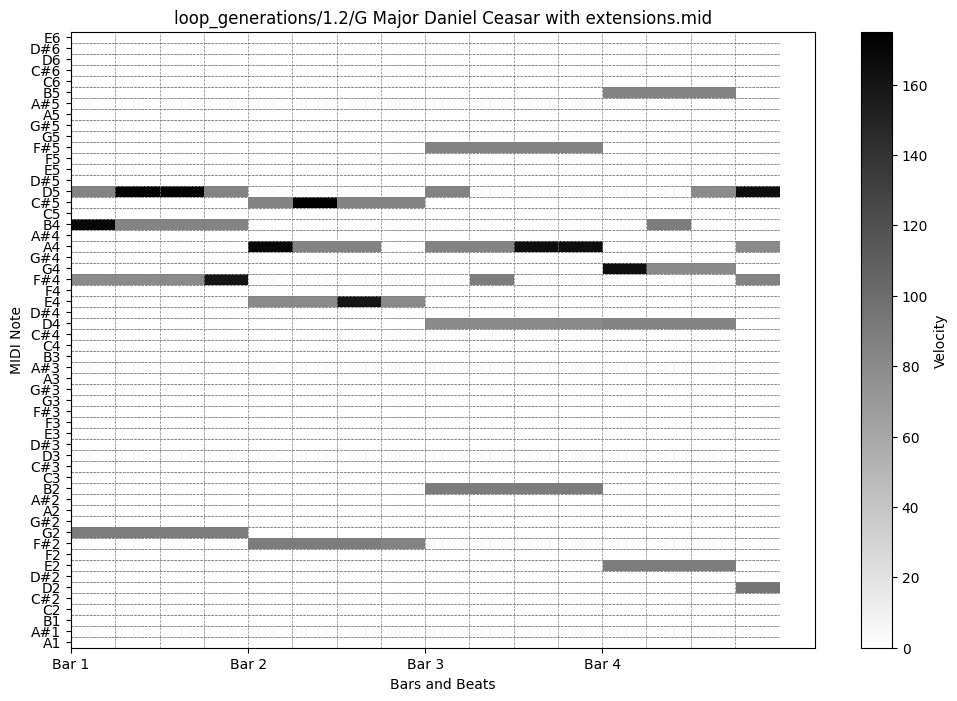

In [32]:
mel_gen = generate_melody(msgs)
add_melody_to_midi(mel_gen, f"loop_generations/{t}/{key} {mode} {keywords}.mid", f"{t}/{key} {mode} {keywords}.mid")
visualize_midi(f"loop_generations/{t}/{key} {mode} {keywords}.mid")
play_midi(f"loop_generations/{t}/{key} {mode} {keywords}.mid")